In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix
CUDA_LAUNCH_BLOCKING=1

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^3)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): #x为数据，a，b均为中心点
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


### noise=5%

In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=10
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=2
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_5 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_5 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_5 = -F_mea_db_x21 + F_mea_db_x22
F_5=org_m.F(F_mea_b_5,F_mea_db_x1_5,F_mea_db_x2_5)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [3]:
M=3200
af="Tanh"   #先用tanh
R_m=20
cupy_device= 2
models = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/torch/cuda/__init__.py:546: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


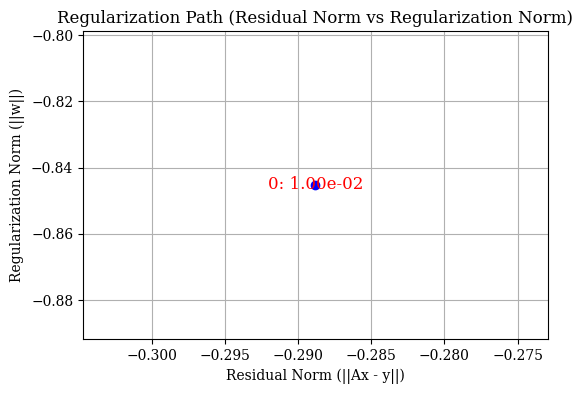

第 0 次迭代的train误差：
第 0 次迭代的泛化误差：


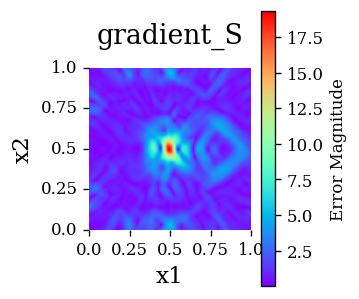

S_l_inf= 2.3189241837741155 S_L_2= 0.36225033494688796 S_l_2= 0.8020271304110008


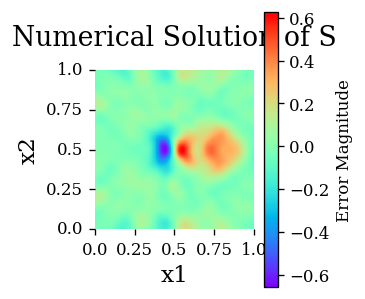

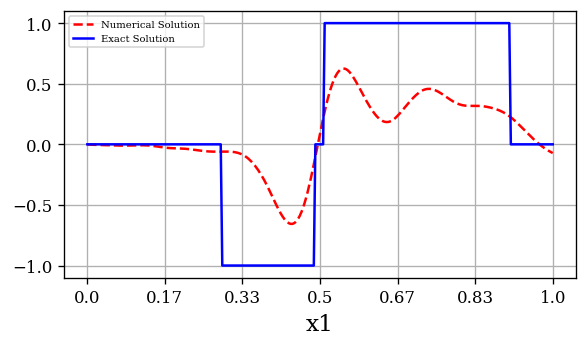

第 0 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


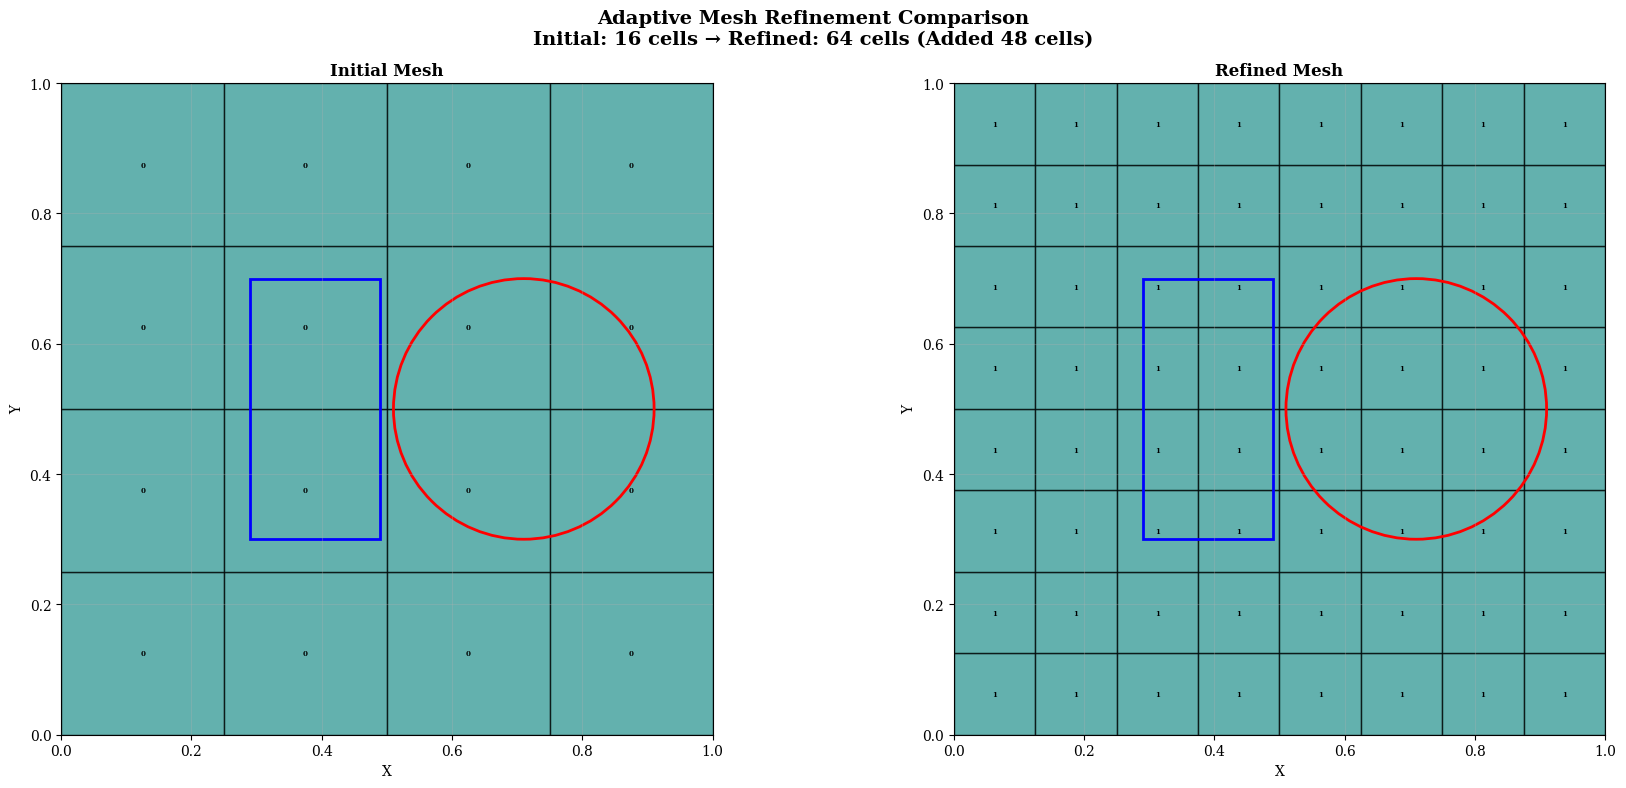

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


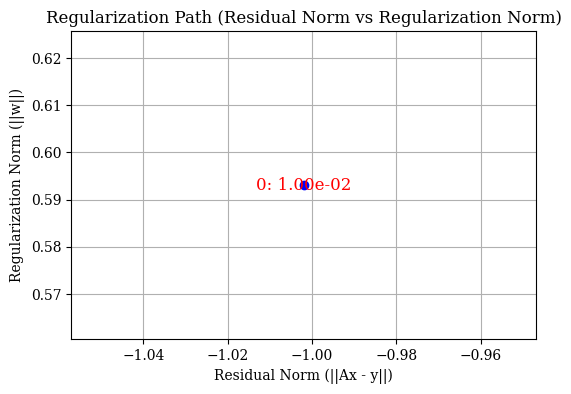

第 1 次迭代的train误差：
第 1 次迭代的泛化误差：


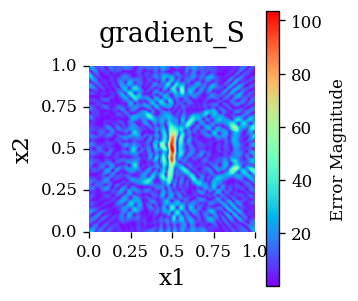

S_l_inf= 3.2303059709990367 S_L_2= 0.23705223836543346 S_l_2= 0.5248368549379211


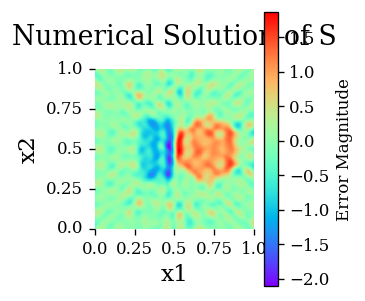

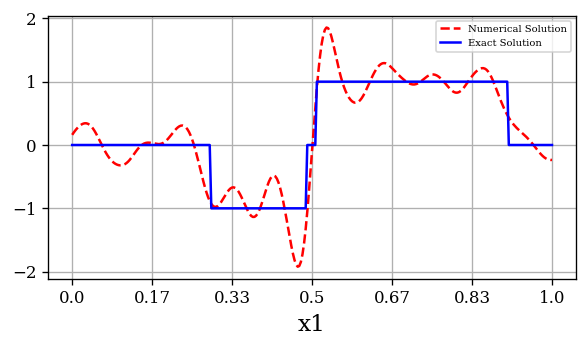

第 1 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


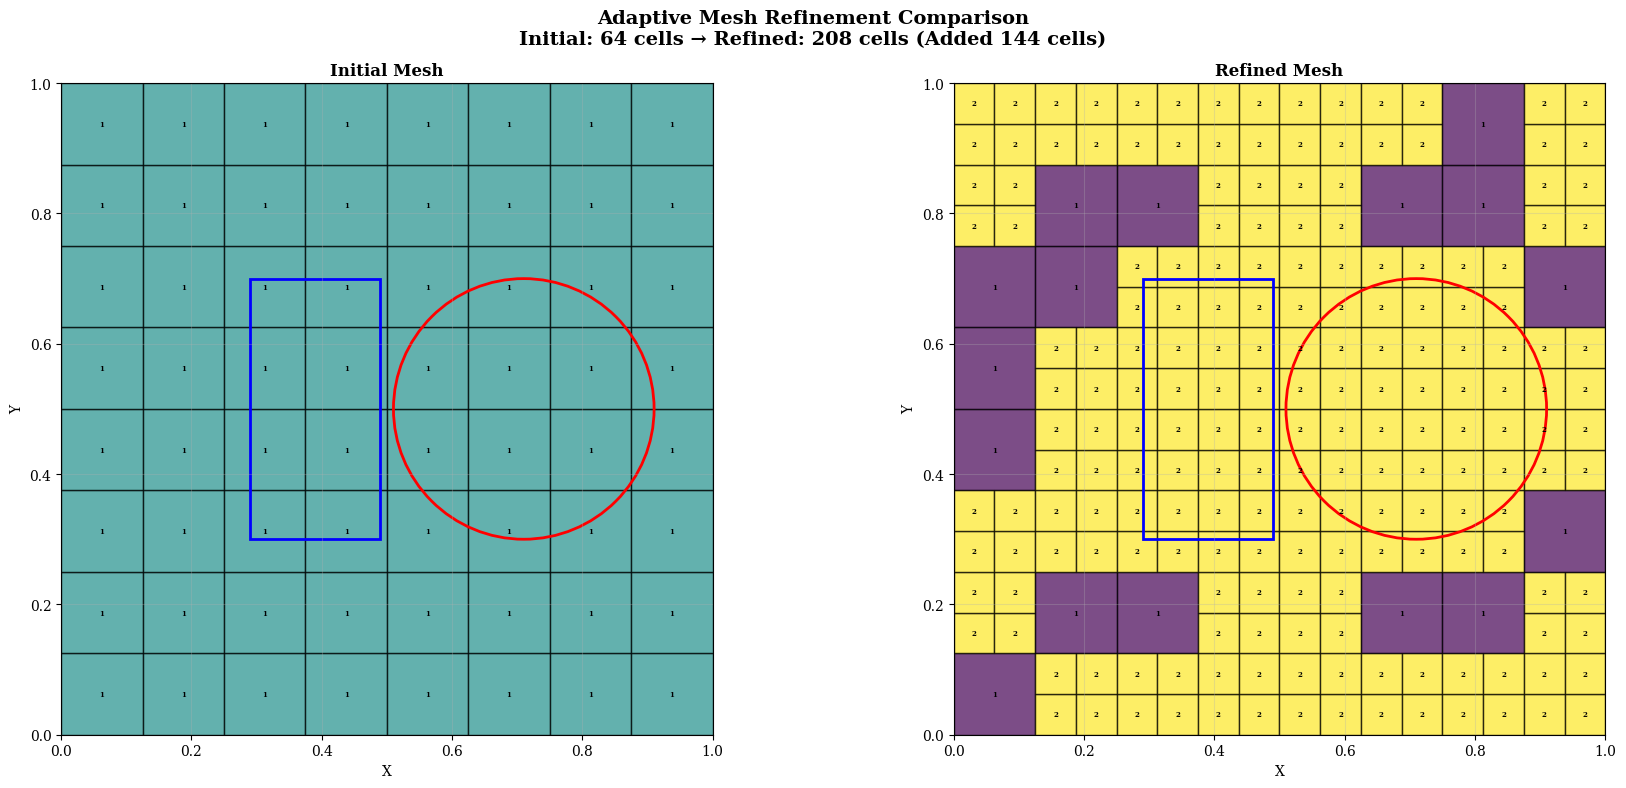

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


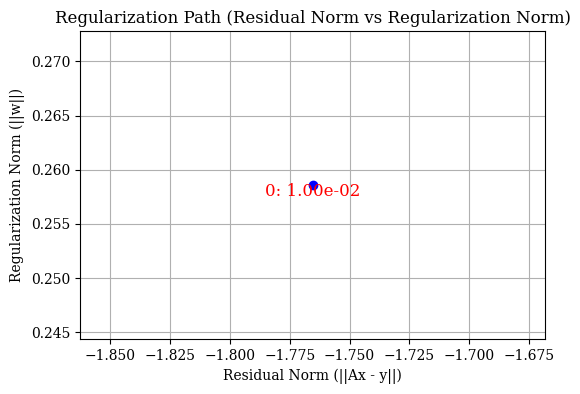

第 2 次迭代的train误差：
第 2 次迭代的泛化误差：


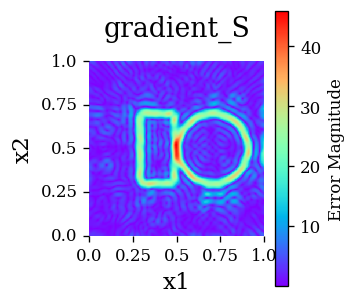

S_l_inf= 1.8282721997542295 S_L_2= 0.09825663189052716 S_l_2= 0.2175415090521962


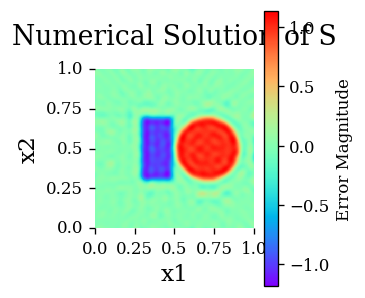

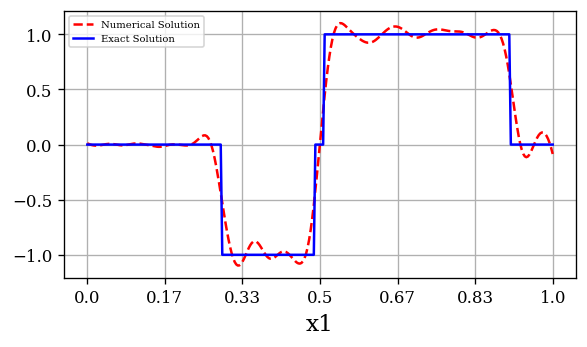

第 2 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


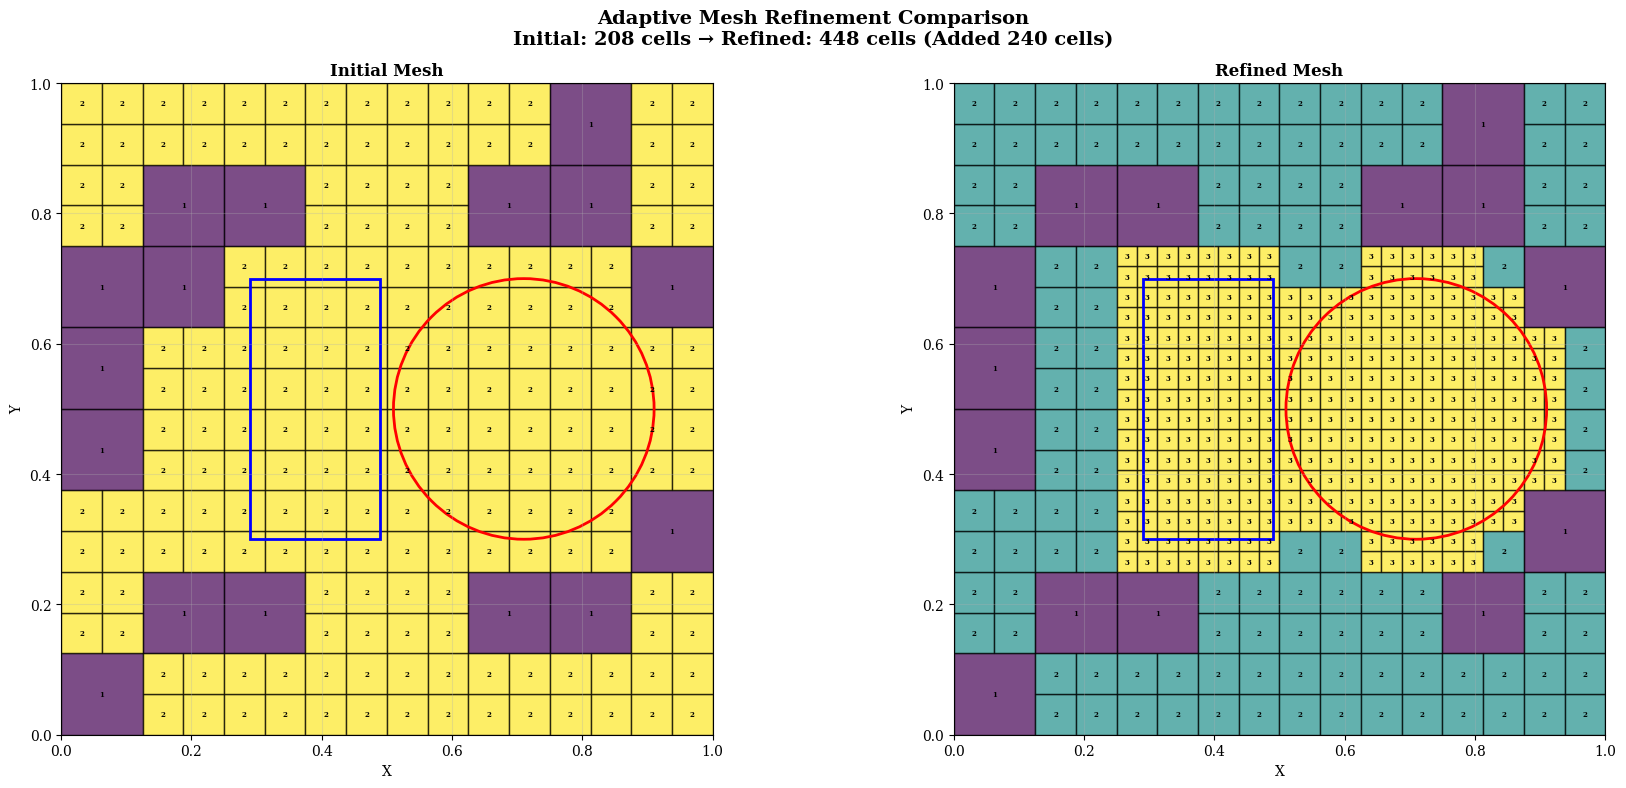

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


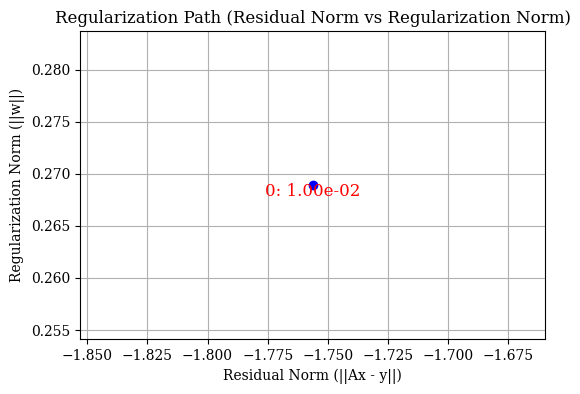

第 3 次迭代的train误差：
第 3 次迭代的泛化误差：


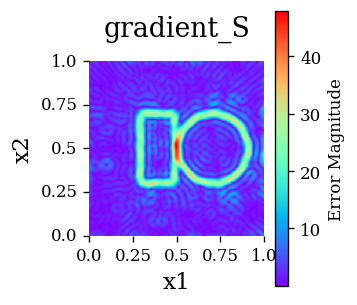

S_l_inf= 1.8403323137591023 S_L_2= 0.09686534866428001 S_l_2= 0.21446118921287965


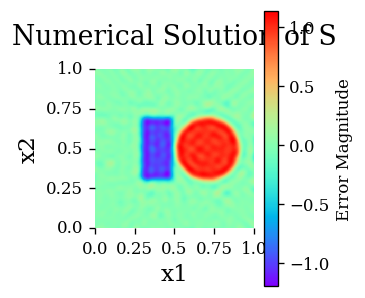

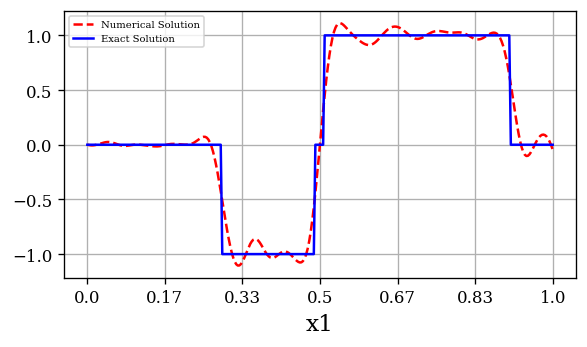

第 3 次自适应网格细分...
Generating visualizations...
1. Plotting mesh comparison...


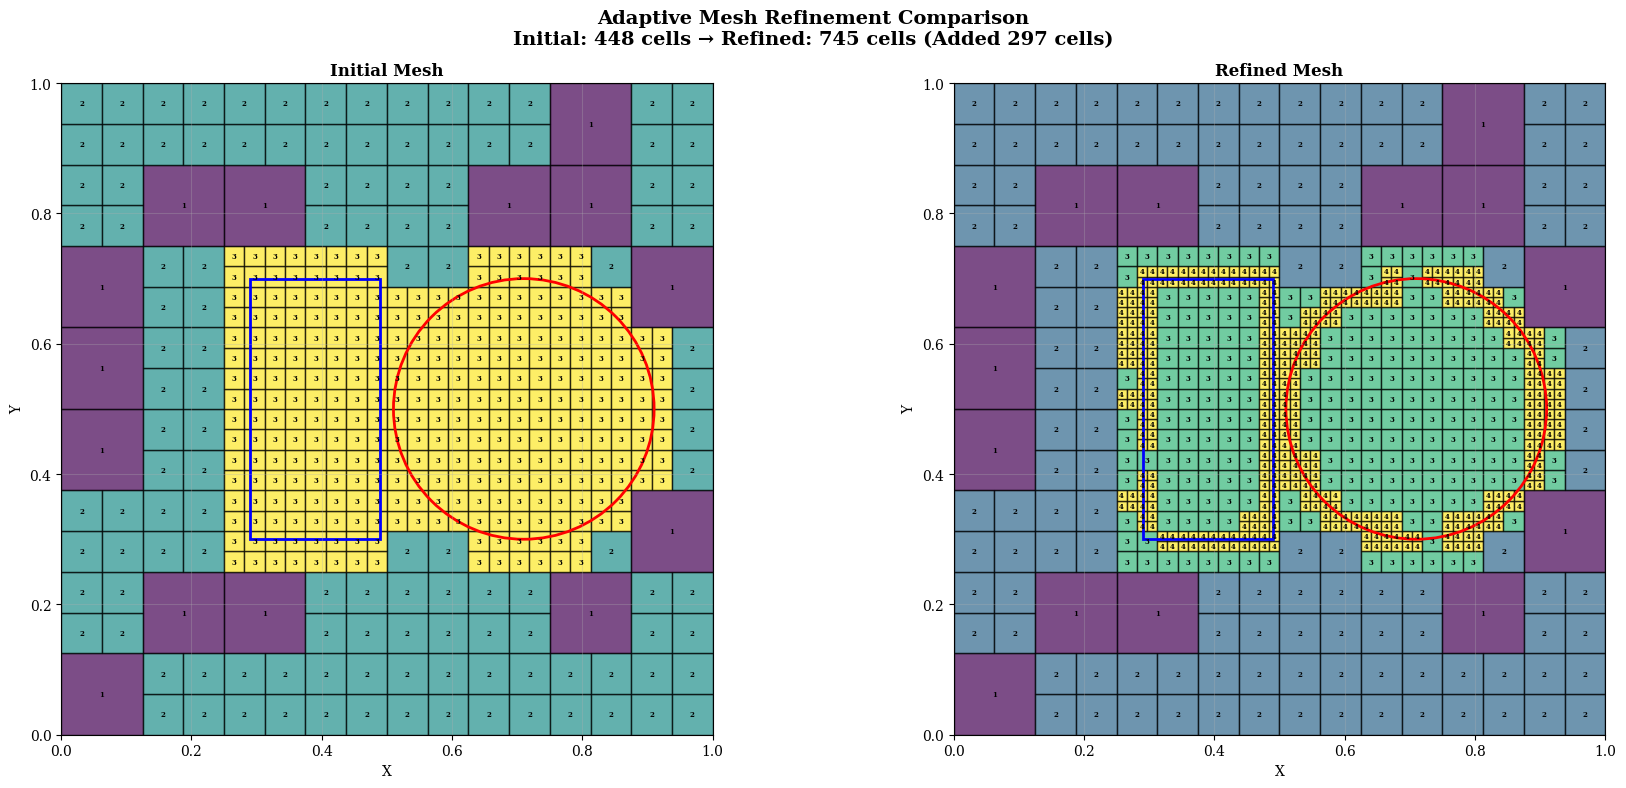

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


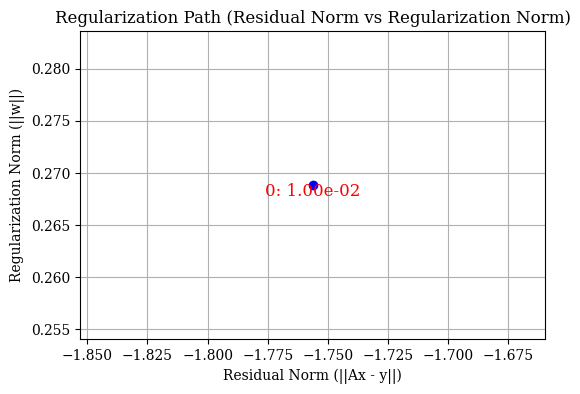

第 4 次迭代的train误差：
第 4 次迭代的泛化误差：


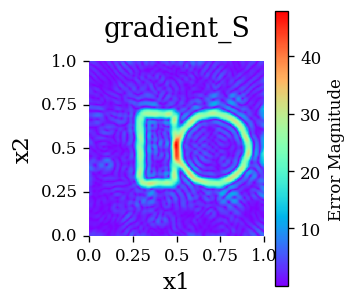

S_l_inf= 1.840147176659987 S_L_2= 0.09686490931995444 S_l_2= 0.21446021649861355


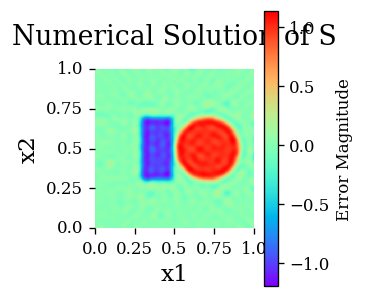

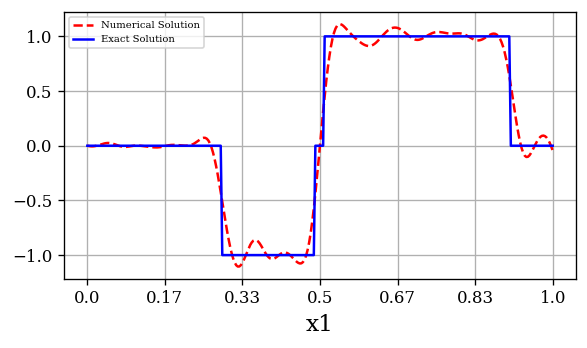

在第 4 次迭代结束


In [4]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
refine_threshold_S=[1e-4, 5e-4, 1e-3, 5e-3, 1e-2] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[1e-8, 5e-8, 1e-7, 5e-7, 1e-6]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
Shape=[]
cells_store,refinement_stats_store,w_,point_number,S_num_store,g_store,g_S,S_l2=main_fix.ada_int(iter_int,delta,cells,nx,models,M,af,Shape,kk,F_5,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

Number of detected clusters: 2
CurvStd=0.264, PeakRatio=20.72 
Cluster 0: AR=1.97
  Res_Rect=0.034 vs Res_Ellip=0.145
  -> Winner: Rectangle
  CV of S_num: 0.249
Cluster 0: Lx=0.207, Ly=0.407, AR=1.97
  -> Decision: Rectangle (Sigmoid)
CurvStd=0.391, PeakRatio=8.44 
Cluster 1: AR=1.01
  Res_Rect=0.095 vs Res_Ellip=0.018
  -> Winner: Circle
  CV of S_num: 0.244
Cluster 1: Lx=0.397, Ly=0.400, AR=1.01
  -> Decision: Circle (Sigmoid)


/mnt/store/hxw-y23/two_objects_rec_circle_close/M变化对比实验/../main_code2/bound_detect.py:435: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


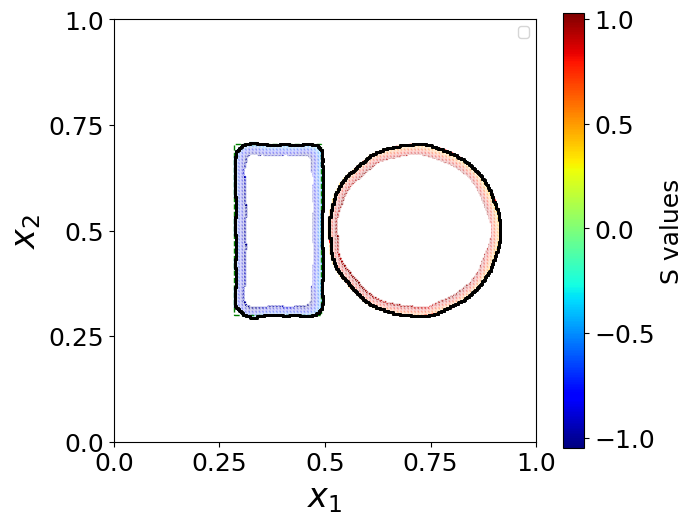

<Figure size 640x480 with 0 Axes>

In [ ]:
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.01
mini_samples=20
para_abs=3
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./MA_RFM_5%/M=3200+1600*2", output_filename="plot.png")

In [8]:
results

[{'cluster_id': 0,
  'shape': 'Rectangle',
  'params': {'center': array([0.38670038, 0.50281641]),
   'W': 0.20666666666666667,
   'H': 0.4066666666666667},
  'profile': 'Sigmoid'},
 {'cluster_id': 1,
  'shape': 'Circle',
  'params': {'center': array([0.71260285, 0.50077257]),
   'radius': 0.20328894018536064},
  'profile': 'Sigmoid'}]

In [9]:
center1=results[0]['params']['center']
width=results[0]['params']['W']
height=results[0]['params']['H']
center2=results[1]['params']['center']
r=results[1]['params']['radius']


In [28]:
import net_2D_fix2

r_min=(1-0.1)*r
r_max=(1+0.05)*r
K_min=1000
K_max=20000
min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
min_c1,max_c1,min_c2,max_c2=-center2[0]*(1+0.05),-center2[0]*(1-0.05),-center2[1]*(1+0.05),-center2[1]*(1-0.05)
width_min,width_max=width*(1-0.1),width*(1+0.05)
height_min,height_max=height*(1-0.1),height*(1+0.05)
models0=models
#models0= net_2D_fix2.pre_define(Nx, Ny,1600,3,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],K_min,K_max,[],device)
models1= net_2D_fix2.pre_define(Nx, Ny,1600,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,min_c1,max_c1,min_c2,max_c2,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
models2= net_2D_fix2.pre_define(Nx, Ny,1600,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_min,K_max,"rec",device)
af="mix"
sum_mat,all_g_p1,all_g_n,cells_copy1=cal_S_grad.mat_assemble2(cells_store[-1],models0,models1,models2,"mix","circle","rec",kk,0,points_b,device,cupy_device)


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


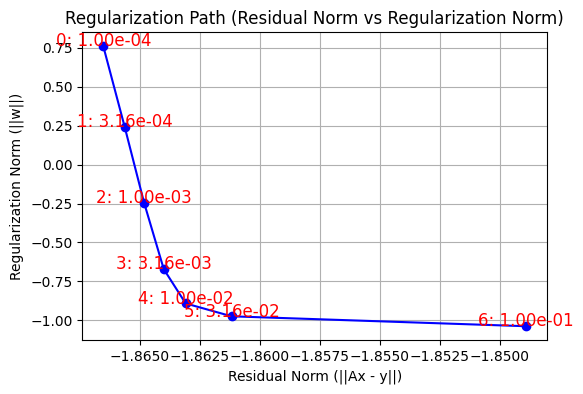

In [29]:
lamb_regu=np.logspace(-4,-1,7,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F_5,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解q


lamb: 0.0001


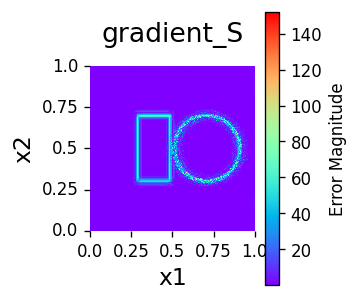

S_l_inf= 1.58496148283565 S_L_2= 0.06777348607983458 S_l_2= 0.15005141283452278


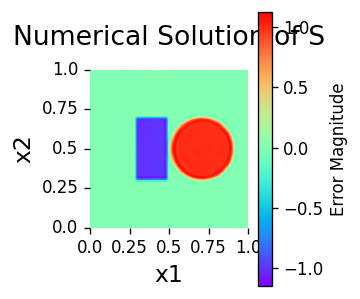

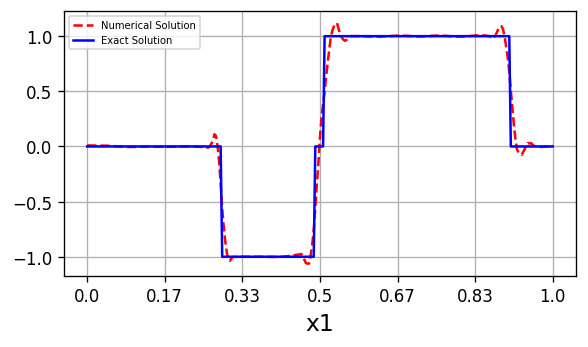

In [32]:
lamb=lamb_regu[4]**2
print('lamb:',lamb)
Qx,Qy=150,150
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2D.test(models0,models1,models2,[],Qx,Qy,w_store[:,4],"mix","circle","rec",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [ ]:
np.save("./MA_RFM_5%/M=3200+1600*2/g_S1",g_SS)

In [ ]:
import pickle

with open("./MA_RFM_5%/M=3200+1600*2/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [ ]:
np.save(f"./MA_RFM_5%/M=3200+1600*2/S_num_3200+1600*2_{lamb}",S_test_num)
np.save("./MA_RFM_5%/M=3200+1600*2/all_mat",sum_mat)
np.save("./MA_RFM_5%/M=3200+1600*2/w_store",w_store)
np.save("./MA_RFM_5%/M=3200+1600*2/F_mea_b",F_mea_b_5)
np.save("./MA_RFM_5%/M=3200+1600*2/F_mea_db_x1",F_mea_db_x1_5)
np.save("./MA_RFM_5%/M=3200+1600*2/F_mea_db_x2",F_mea_db_x2_5)

In [ ]:
# 保存 models1 模型
torch.save(models0,f"./MA_RFM_5%/M=3200+1600*2/models0_33_3200_{point_number[-1]}_{lamb}.pth")
torch.save(models1,f"./MA_RFM_5%/M=3200+1600*2/models1_33_1600_circle.pth")
torch.save(models2,f"./MA_RFM_5%/M=3200+1600*2/models2_33_1600_rec.pth")

In [ ]:
np.save("./MA_RFM_5%/M=3200+1600*2/g_S1",g_SS)

In [38]:
parameters5 = {
    "I_grid":Ix,
    "gauss_n":nx,
    "number_gene":number_gene,
    "noise":eps,
    "k": kk,
    "M0": 3200,
    "M1": 1600,
    "M2": 1600,
    "Tanh_Rm":20,
    "Gauss_R_m": R_m,
    "refinement_stats_store":refinement_stats_store,
    "points_number_ada:":point_number,
    "r_min": r_min,
    "r_max": r_max,
    "min_rec1": min_rec1,
    "max_rec1": max_rec1,
    "min_rec2": min_rec1,
    "max_rec2": max_rec1,
    "width_min": width_min,
    "width_max": width_max,
    "height_min": height_min,
    "height_max": height_max,
    "min_circle1":min_c1,
    "max_circle1":max_c1,
    "min_circle2":min_c2,
    "max_circle2":max_c2,
    "K_min": K_min,
    "K_max": K_max,
}

In [39]:
## 帮我打印 n_integral:len(cell_stores[-1])*9, center[0],width,height, center[1], r, S_l2[-1], lamb_regu**2, S_l21
#打印成列表形式 
n_integral=len(cells_store[-1])*9
print('n_integral:',n_integral)
print('center1[0]:',center1)
print('center2[1]:',center2)
print('width:',width)
print('height:',height)

print('r:',r)
print('S_l2[-1]:',S_l2[-1])
print('lamb_regu:',lamb)
print('S_l21:',S_l_21)

n_integral: 6705
center1[0]: [0.38670038 0.50281641]
center2[1]: [0.71260285 0.50077257]
width: 0.20666666666666667
height: 0.4066666666666667
r: 0.20328894018536064
S_l2[-1]: 0.21446021649861355
lamb_regu: 0.0001
S_l21: 0.15005141283452278
